<a href="https://colab.research.google.com/github/HiraNawaz2415/DL-Assignment-1/blob/main/Optimizers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Optimizer and its Types (Basic & Advance)

- A 2-layer neural network (input → hidden → output)
- Activation function: ReLU for hidden layer, linear output (for regression)
- MSE loss
- Optimizers: SGD, Mini Batch, Momentum, RMSProp, Adam, AdaGrad

# Optimizers and Their Formulas (with Variable Explanation)

| Optimizer          | Update Formula | Explanation |
|-------------------|----------------|-------------|
| **SGD** | $\displaystyle \theta_{t+1} = \theta_t - \eta \nabla_\theta J(\theta_t)$ | $\theta_t$: current parameters<br> $\theta_{t+1}$: updated parameters<br> $\eta$: learning rate<br> $\nabla_\theta J(\theta_t)$: gradient of loss w.r.t parameters |
| **Momentum** | $\displaystyle v_t = \beta v_{t-1} + (1-\beta) \nabla_\theta J(\theta_t) <br> \theta_{t+1} = \theta_t - \eta v_t$ | $v_t$: velocity update<br> $v_{t-1}$: previous velocity<br> $\beta$: momentum factor (0.9 typical)<br> $\eta$: learning rate<br> $\nabla_\theta J(\theta_t)$: gradient |
| **RMSProp** | $\displaystyle E[g^2]_t = \rho E[g^2]_{t-1} + (1-\rho) (\nabla_\theta J(\theta_t))^2 <br> \theta_{t+1} = \theta_t - \frac{\eta}{\sqrt{E[g^2]_t + \epsilon}} \nabla_\theta J(\theta_t)$ | $E[g^2]_t$: running avg of squared gradients<br> $\rho$: decay rate (0.9 typical)<br> $\eta$: learning rate<br> $\epsilon$: small value to avoid div by zero<br> $\nabla_\theta J(\theta_t)$: gradient |
| **Adam** | $\displaystyle m_t = \beta_1 m_{t-1} + (1-\beta_1) \nabla_\theta J(\theta_t) <br> v_t = \beta_2 v_{t-1} + (1-\beta_2) (\nabla_\theta J(\theta_t))^2 <br> \hat{m}_t = \frac{m_t}{1-\beta_1^t}, \hat{v}_t = \frac{v_t}{1-\beta_2^t} <br> \theta_{t+1} = \theta_t - \frac{\eta}{\sqrt{\hat{v}_t} + \epsilon} \hat{m}_t$ | $m_t$: first moment (mean)<br> $v_t$: second moment (variance)<br> $\beta_1, \beta_2$: decay rates (0.9,0.999)<br> $\hat{m}_t, \hat{v}_t$: bias-corrected moments<br> $\eta$: learning rate<br> $\epsilon$: small value to avoid div by zero |
| **Mini-Batch SGD** | $\displaystyle \theta_{t+1} = \theta_t - \eta \frac{1}{B} \sum_{i=1}^{B} \nabla_\theta J_i(\theta_t)$ | $B$: mini-batch size<br> $\nabla_\theta J_i(\theta_t)$: gradient for each sample in batch<br> $\eta$: learning rate<br> $\theta_t, \theta_{t+1}$: params before/after update |
| **AdaGrad** | $\displaystyle G_t = G_{t-1} + (\nabla_\theta J(\theta_t))^2 <br> \theta_{t+1} = \theta_t - \frac{\eta}{\sqrt{G_t} + \epsilon} \nabla_\theta J(\theta_t)$ | $G_t$: sum of squares of past gradients<br> $\nabla_\theta J(\theta_t)$: gradient<br> $\eta$: learning rate<br> $\epsilon$: small value to avoid div by zero |


In [5]:
import numpy as np  # numerical computations
from sklearn.datasets import load_diabetes  # regression dataset
from sklearn.model_selection import train_test_split  # split dataset
from sklearn.preprocessing import StandardScaler  # feature scaling


#### Dataset Preparation

In [6]:
# Load diabetes dataset
data = load_diabetes() # built in dataset of sklearn
X = data.data  # features
y = data.target.reshape(-1, 1)  # column vector for regression

In [7]:
X

array([[ 0.03807591,  0.05068012,  0.06169621, ..., -0.00259226,
         0.01990749, -0.01764613],
       [-0.00188202, -0.04464164, -0.05147406, ..., -0.03949338,
        -0.06833155, -0.09220405],
       [ 0.08529891,  0.05068012,  0.04445121, ..., -0.00259226,
         0.00286131, -0.02593034],
       ...,
       [ 0.04170844,  0.05068012, -0.01590626, ..., -0.01107952,
        -0.04688253,  0.01549073],
       [-0.04547248, -0.04464164,  0.03906215, ...,  0.02655962,
         0.04452873, -0.02593034],
       [-0.04547248, -0.04464164, -0.0730303 , ..., -0.03949338,
        -0.00422151,  0.00306441]])

In [8]:
print(data.feature_names)

['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']


In [9]:
y

array([[151.],
       [ 75.],
       [141.],
       [206.],
       [135.],
       [ 97.],
       [138.],
       [ 63.],
       [110.],
       [310.],
       [101.],
       [ 69.],
       [179.],
       [185.],
       [118.],
       [171.],
       [166.],
       [144.],
       [ 97.],
       [168.],
       [ 68.],
       [ 49.],
       [ 68.],
       [245.],
       [184.],
       [202.],
       [137.],
       [ 85.],
       [131.],
       [283.],
       [129.],
       [ 59.],
       [341.],
       [ 87.],
       [ 65.],
       [102.],
       [265.],
       [276.],
       [252.],
       [ 90.],
       [100.],
       [ 55.],
       [ 61.],
       [ 92.],
       [259.],
       [ 53.],
       [190.],
       [142.],
       [ 75.],
       [142.],
       [155.],
       [225.],
       [ 59.],
       [104.],
       [182.],
       [128.],
       [ 52.],
       [ 37.],
       [170.],
       [170.],
       [ 61.],
       [144.],
       [ 52.],
       [128.],
       [ 71.],
       [163.],
       [15

In [10]:
X.shape

(442, 10)

In [11]:
y.shape

(442, 1)

In [12]:
# Standardize features for better convergence
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [13]:
# Split into train/test sets (80%-20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#### Neural Network Forward & Backward Functions

In [14]:
# Activation functions
def relu(Z):
    return np.maximum(0, Z)  # ReLU: max(0, Z)

def relu_derivative(Z):
    return (Z > 0).astype(float)  # derivative of ReLU


In [15]:
# Forward pass for 2-layer NN
def forward(X, W1, b1, W2, b2):
    Z1 = np.dot(X, W1) + b1  # hidden layer linear
    A1 = relu(Z1)            # hidden layer activation
    Z2 = np.dot(A1, W2) + b2 # output layer linear
    y_pred = Z2               # linear output for regression
    cache = (X, Z1, A1, Z2)
    return y_pred, cache

In [16]:
# Compute MSE Loss
def mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

In [17]:
# Backward pass: compute gradients
def backward(y_true, y_pred, cache, W2):
    X, Z1, A1, Z2 = cache
    m = X.shape[0]  # number of samples

    dZ2 = (2/m) * (y_pred - y_true)        # derivative of loss w.r.t output
    dW2 = np.dot(A1.T, dZ2)                # gradient for output weights
    db2 = np.sum(dZ2, axis=0, keepdims=True)  # gradient for output bias

    dA1 = np.dot(dZ2, W2.T)                # backprop to hidden activation
    dZ1 = dA1 * relu_derivative(Z1)        # backprop through ReLU
    dW1 = np.dot(X.T, dZ1)                 # gradient for hidden weights
    db1 = np.sum(dZ1, axis=0, keepdims=True)  # gradient for hidden bias

    return dW1, db1, dW2, db2

## Optimizers for Neural Network

##### 1. SGD

In [18]:
def train_sgd(X, y, hidden_size=32, lr=0.01, epochs=200):
    """
    Train a 2-layer neural network using Stochastic Gradient Descent (SGD)
    X: input features, shape (n_samples, n_features)
    y: target values, shape (n_samples, 1)
    hidden_size: number of neurons in hidden layer
    lr: learning rate
    epochs: number of iterations over the whole dataset
    """

    input_size = X.shape[1]       # number of input features (columns in X)
    output_size = y.shape[1]      # number of output neurons (usually 1 for regression)

    # ------------------------
    # Initialize weights randomly
    # ------------------------
    W1 = np.random.randn(input_size, hidden_size) * 0.01  # weights for input -> hidden
    b1 = np.zeros((1, hidden_size))                        # bias for hidden layer
    W2 = np.random.randn(hidden_size, output_size) * 0.01 # weights for hidden -> output
    b2 = np.zeros((1, output_size))                        # bias for output layer

    losses = []  # list to store loss at each epoch for plotting

    # ------------------------
    # Training loop over epochs
    # ------------------------
    for epoch in range(epochs):
        # Forward pass: compute predictions and cache intermediate values
        y_pred, cache = forward(X, W1, b1, W2, b2)  # cache needed for backprop

        # Compute Mean Squared Error loss
        loss = mse(y, y_pred)

        # Store loss for this epoch to track training progress
        losses.append(loss)

        # Backward pass: compute gradients for all weights and biases
        dW1, db1, dW2, db2 = backward(y, y_pred, cache, W2)

        # ------------------------
        # Update weights using SGD rule
        # ------------------------
        W1 -= lr * dW1  # update hidden layer weights
        b1 -= lr * db1  # update hidden layer bias
        W2 -= lr * dW2  # update output layer weights
        b2 -= lr * db2  # update output layer bias

    # Return final trained weights, biases, and list of loss per epoch
    return W1, b1, W2, b2, losses

##### 2. Mini batch

In [48]:
def train_sgd_minibatch(X, y, hidden_size=32, lr=0.001, epochs=200, batch_size=32):
    input_size = X.shape[1]
    output_size = y.shape[1]

    # Xavier Initialization
    W1 = np.random.randn(input_size, hidden_size) * np.sqrt(2/input_size)
    b1 = np.zeros((1, hidden_size))
    W2 = np.random.randn(hidden_size, output_size) * np.sqrt(2/hidden_size)
    b2 = np.zeros((1, output_size))

    losses = []

    for epoch in range(epochs):
        mini_batches = create_mini_batches(X, y, batch_size=batch_size, shuffle=True)
        epoch_loss = 0

        for X_batch, y_batch in mini_batches:
            y_pred, cache = forward(X_batch, W1, b1, W2, b2)
            loss = mse(y_batch, y_pred)
            epoch_loss += loss

            dW1, db1, dW2, db2 = backward(y_batch, y_pred, cache, W2)

            # Optional: clip gradients
            dW1 = np.clip(dW1, -1, 1)
            db1 = np.clip(db1, -1, 1)
            dW2 = np.clip(dW2, -1, 1)
            db2 = np.clip(db2, -1, 1)

            # Update weights
            W1 -= lr * dW1
            b1 -= lr * db1
            W2 -= lr * dW2
            b2 -= lr * db2

        epoch_loss /= len(mini_batches)  # average per mini-batch
        losses.append(epoch_loss)

    return W1, b1, W2, b2, losses

##### 3. Momentum

In [20]:
def train_momentum(X, y, hidden_size=32, lr=0.01, beta=0.9, epochs=200):
    """
    Train 2-layer neural network using SGD with Momentum
    X: input features
    y: target values
    hidden_size: neurons in hidden layer
    lr: learning rate
    beta: momentum coefficient (0 < beta < 1)
    epochs: number of iterations
    """
    input_size = X.shape[1]      # number of input features
    output_size = y.shape[1]     # output dimension

    # Initialize weights randomly
    W1 = np.random.randn(input_size, hidden_size) * 0.01
    b1 = np.zeros((1, hidden_size))
    W2 = np.random.randn(hidden_size, output_size) * 0.01
    b2 = np.zeros((1, output_size))

    # Initialize velocity terms for momentum (same shape as weights)
    vW1 = np.zeros_like(W1)
    vb1 = np.zeros_like(b1)
    vW2 = np.zeros_like(W2)
    vb2 = np.zeros_like(b2)

    losses = []  # store MSE loss for each epoch

    # Training loop
    for epoch in range(epochs):
        # Forward pass
        y_pred, cache = forward(X, W1, b1, W2, b2)

        # Compute loss
        loss = mse(y, y_pred)
        losses.append(loss)

        # Backward pass: compute gradients
        dW1, db1, dW2, db2 = backward(y, y_pred, cache, W2)

        # ------------------------
        # Update velocities with momentum
        # ------------------------
        vW1 = beta * vW1 + (1 - beta) * dW1  # hidden layer weights
        vb1 = beta * vb1 + (1 - beta) * db1  # hidden layer bias
        vW2 = beta * vW2 + (1 - beta) * dW2  # output layer weights
        vb2 = beta * vb2 + (1 - beta) * db2  # output layer bias

        # ------------------------
        # Update weights using velocities
        # ------------------------
        W1 -= lr * vW1
        b1 -= lr * vb1
        W2 -= lr * vW2
        b2 -= lr * vb2

    # Return trained weights, biases, and loss history
    return W1, b1, W2, b2, losses


##### 4. RMSProp

In [21]:
def train_rmsprop(X, y, hidden_size=32, lr=0.001, beta=0.9, epsilon=1e-8, epochs=200):
    """
    Train 2-layer neural network using RMSProp optimizer
    lr: learning rate
    beta: decay rate for moving average of squared gradients
    epsilon: small constant to avoid division by zero
    """
    input_size = X.shape[1]
    output_size = y.shape[1]

    # Initialize weights
    W1 = np.random.randn(input_size, hidden_size) * 0.01
    b1 = np.zeros((1, hidden_size))
    W2 = np.random.randn(hidden_size, output_size) * 0.01
    b2 = np.zeros((1, output_size))

    # Initialize squared gradient accumulators
    sW1 = np.zeros_like(W1)
    sb1 = np.zeros_like(b1)
    sW2 = np.zeros_like(W2)
    sb2 = np.zeros_like(b2)

    losses = []

    for epoch in range(epochs):
        # Forward pass
        y_pred, cache = forward(X, W1, b1, W2, b2)

        # Compute loss
        loss = mse(y, y_pred)
        losses.append(loss)

        # Backward pass
        dW1, db1, dW2, db2 = backward(y, y_pred, cache, W2)

        # ------------------------
        # Accumulate squared gradients (exponentially weighted)
        # ------------------------
        sW1 = beta * sW1 + (1 - beta) * (dW1 ** 2)
        sb1 = beta * sb1 + (1 - beta) * (db1 ** 2)
        sW2 = beta * sW2 + (1 - beta) * (dW2 ** 2)
        sb2 = beta * sb2 + (1 - beta) * (db2 ** 2)

        # ------------------------
        # Update weights using RMSProp rule
        # ------------------------
        W1 -= lr * dW1 / (np.sqrt(sW1) + epsilon)
        b1 -= lr * db1 / (np.sqrt(sb1) + epsilon)
        W2 -= lr * dW2 / (np.sqrt(sW2) + epsilon)
        b2 -= lr * db2 / (np.sqrt(sb2) + epsilon)

    return W1, b1, W2, b2, losses

##### 5. Adam

In [22]:
def train_adam(X, y, hidden_size=32, lr=0.001, beta1=0.9, beta2=0.999, epsilon=1e-8, epochs=200):
    """
    Train 2-layer neural network using Adam optimizer
    Combines momentum (first moment) and RMSProp (second moment)
    """
    input_size = X.shape[1]
    output_size = y.shape[1]

    # Initialize weights
    W1 = np.random.randn(input_size, hidden_size) * 0.01
    b1 = np.zeros((1, hidden_size))
    W2 = np.random.randn(hidden_size, output_size) * 0.01
    b2 = np.zeros((1, output_size))

    # Initialize first (m) and second (v) moments for weights and biases
    mW1 = np.zeros_like(W1)
    vW1 = np.zeros_like(W1)
    mb1 = np.zeros_like(b1)
    vb1 = np.zeros_like(b1)
    mW2 = np.zeros_like(W2)
    vW2 = np.zeros_like(W2)
    mb2 = np.zeros_like(b2)
    vb2 = np.zeros_like(b2)

    losses = []

    for t in range(1, epochs + 1):
        # Forward pass
        y_pred, cache = forward(X, W1, b1, W2, b2)

        # Compute loss
        loss = mse(y, y_pred)
        losses.append(loss)

        # Backward pass
        dW1, db1, dW2, db2 = backward(y, y_pred, cache, W2)

        # ------------------------
        # Update first moments (momentum)
        # ------------------------
        mW1 = beta1 * mW1 + (1 - beta1) * dW1
        mb1 = beta1 * mb1 + (1 - beta1) * db1
        mW2 = beta1 * mW2 + (1 - beta1) * dW2
        mb2 = beta1 * mb2 + (1 - beta1) * db2

        # ------------------------
        # Update second moments (RMSProp)
        # ------------------------
        vW1 = beta2 * vW1 + (1 - beta2) * (dW1 ** 2)
        vb1 = beta2 * vb1 + (1 - beta2) * (db1 ** 2)
        vW2 = beta2 * vW2 + (1 - beta2) * (dW2 ** 2)
        vb2 = beta2 * vb2 + (1 - beta2) * (db2 ** 2)

        # ------------------------
        # Bias correction for first and second moments
        # ------------------------
        mW1_hat = mW1 / (1 - beta1 ** t)
        mb1_hat = mb1 / (1 - beta1 ** t)
        mW2_hat = mW2 / (1 - beta1 ** t)
        mb2_hat = mb2 / (1 - beta1 ** t)

        vW1_hat = vW1 / (1 - beta2 ** t)
        vb1_hat = vb1 / (1 - beta2 ** t)
        vW2_hat = vW2 / (1 - beta2 ** t)
        vb2_hat = vb2 / (1 - beta2 ** t)

        # ------------------------
        # Update weights using Adam rule
        # ------------------------
        W1 -= lr * mW1_hat / (np.sqrt(vW1_hat) + epsilon)
        b1 -= lr * mb1_hat / (np.sqrt(vb1_hat) + epsilon)
        W2 -= lr * mW2_hat / (np.sqrt(vW2_hat) + epsilon)
        b2 -= lr * mb2_hat / (np.sqrt(vb2_hat) + epsilon)

    return W1, b1, W2, b2, losses

##### 6. AdaGrad

In [52]:
def train_adagrad(X, y, hidden_size=32, lr=0.01, epsilon=1e-8, epochs=200):
    """
    Train a 2-layer neural network using AdaGrad optimizer
    X: input features
    y: target values
    hidden_size: neurons in hidden layer
    lr: base learning rate
    epsilon: small value to avoid division by zero
    epochs: number of training iterations
    """
    input_size = X.shape[1]       # number of input features
    output_size = y.shape[1]      # number of output neurons

    # Xavier Initialization for weights
    W1 = np.random.randn(input_size, hidden_size) * np.sqrt(2 / input_size)
    b1 = np.zeros((1, hidden_size))
    W2 = np.random.randn(hidden_size, output_size) * np.sqrt(2 / hidden_size)
    b2 = np.zeros((1, output_size))

    # Initialize accumulated squared gradients for AdaGrad
    G_W1 = np.zeros_like(W1)
    G_b1 = np.zeros_like(b1)
    G_W2 = np.zeros_like(W2)
    G_b2 = np.zeros_like(b2)

    losses = []  # store loss per epoch

    # Training loop
    for epoch in range(epochs):
        # Forward pass
        y_pred, cache = forward(X, W1, b1, W2, b2)

        # Compute Mean Squared Error loss
        loss = mse(y, y_pred)
        losses.append(loss)

        # Backward pass to get gradients
        dW1, db1, dW2, db2 = backward(y, y_pred, cache, W2)

        # Update accumulated squared gradients
        G_W1 += dW1 ** 2
        G_b1 += db1 ** 2
        G_W2 += dW2 ** 2
        G_b2 += db2 ** 2

        # Update weights with AdaGrad adjustment
        W1 -= (lr / (np.sqrt(G_W1) + epsilon)) * dW1
        b1 -= (lr / (np.sqrt(G_b1) + epsilon)) * db1
        W2 -= (lr / (np.sqrt(G_W2) + epsilon)) * dW2
        b2 -= (lr / (np.sqrt(G_b2) + epsilon)) * db2

    # Return trained weights, biases, and loss history
    return W1, b1, W2, b2, losses

## Train All Optimizers

In [54]:
epochs = 200    # total number of training epochs
hidden_size = 32  # number of neurons in hidden layer
lr_sgd = 0.01    # learning rate for SGD and Momentum
lr_adv = 0.001   # learning rate for RMSProp and Adam

# -----------------------------
# Train with SGD
# -----------------------------
W1_sgd, b1_sgd, W2_sgd, b2_sgd, losses_sgd = train_sgd(X_train, y_train,
                                                       hidden_size=hidden_size,
                                                       lr=lr_sgd,
                                                       epochs=epochs)
# -----------------------------
# Train with Mini-Batch SGD
# -----------------------------
W1_sgd_mini, b1_sgd_mini, W2_sgd_mini, b2_sgd_mini, losses_sgd_mini = train_sgd_minibatch(
    X_train,               # input features
    y_train,               # target labels
    hidden_size=hidden_size,  # neurons in hidden layer
    lr=lr_sgd,             # learning rate
    epochs=epochs,         # total number of epochs
    batch_size=32          # mini-batch size
)
# -----------------------------
# Train with Momentum
# -----------------------------
W1_mom, b1_mom, W2_mom, b2_mom, losses_mom = train_momentum(X_train, y_train,
                                                           hidden_size=hidden_size,
                                                           lr=lr_sgd,
                                                           beta=0.9,
                                                           epochs=epochs)

# -----------------------------
# Train with RMSProp
# -----------------------------
W1_rms, b1_rms, W2_rms, b2_rms, losses_rms = train_rmsprop(X_train, y_train,
                                                          hidden_size=hidden_size,
                                                          lr=lr_adv,
                                                          beta=0.9,
                                                          epsilon=1e-8,
                                                          epochs=epochs)

# -----------------------------
# Train with Adam
# -----------------------------
W1_adam, b1_adam, W2_adam, b2_adam, losses_adam = train_adam(X_train, y_train,
                                                            hidden_size=hidden_size,
                                                            lr=lr_adv,
                                                            beta1=0.9,
                                                            beta2=0.999,
                                                            epsilon=1e-8,
                                                            epochs=epochs)
# -----------------------------
# Train with AdaGrad
# -----------------------------
W1_adagrad, b1_adagrad, W2_adagrad, b2_adagrad, losses_adagrad = train_adagrad(
    X_train, y_train,
    hidden_size=hidden_size,
    lr=lr_sgd,      # learning rate
    epochs=epochs   # number of training iterations
)

/tmp/ipykernel_4988/2572407946.py:3: RuntimeWarning: overflow encountered in square
  return np.mean((y_true - y_pred) ** 2)
/tmp/ipykernel_4988/2468648806.py:11: RuntimeWarning: invalid value encountered in multiply
  dZ1 = dA1 * relu_derivative(Z1)        # backprop through ReLU


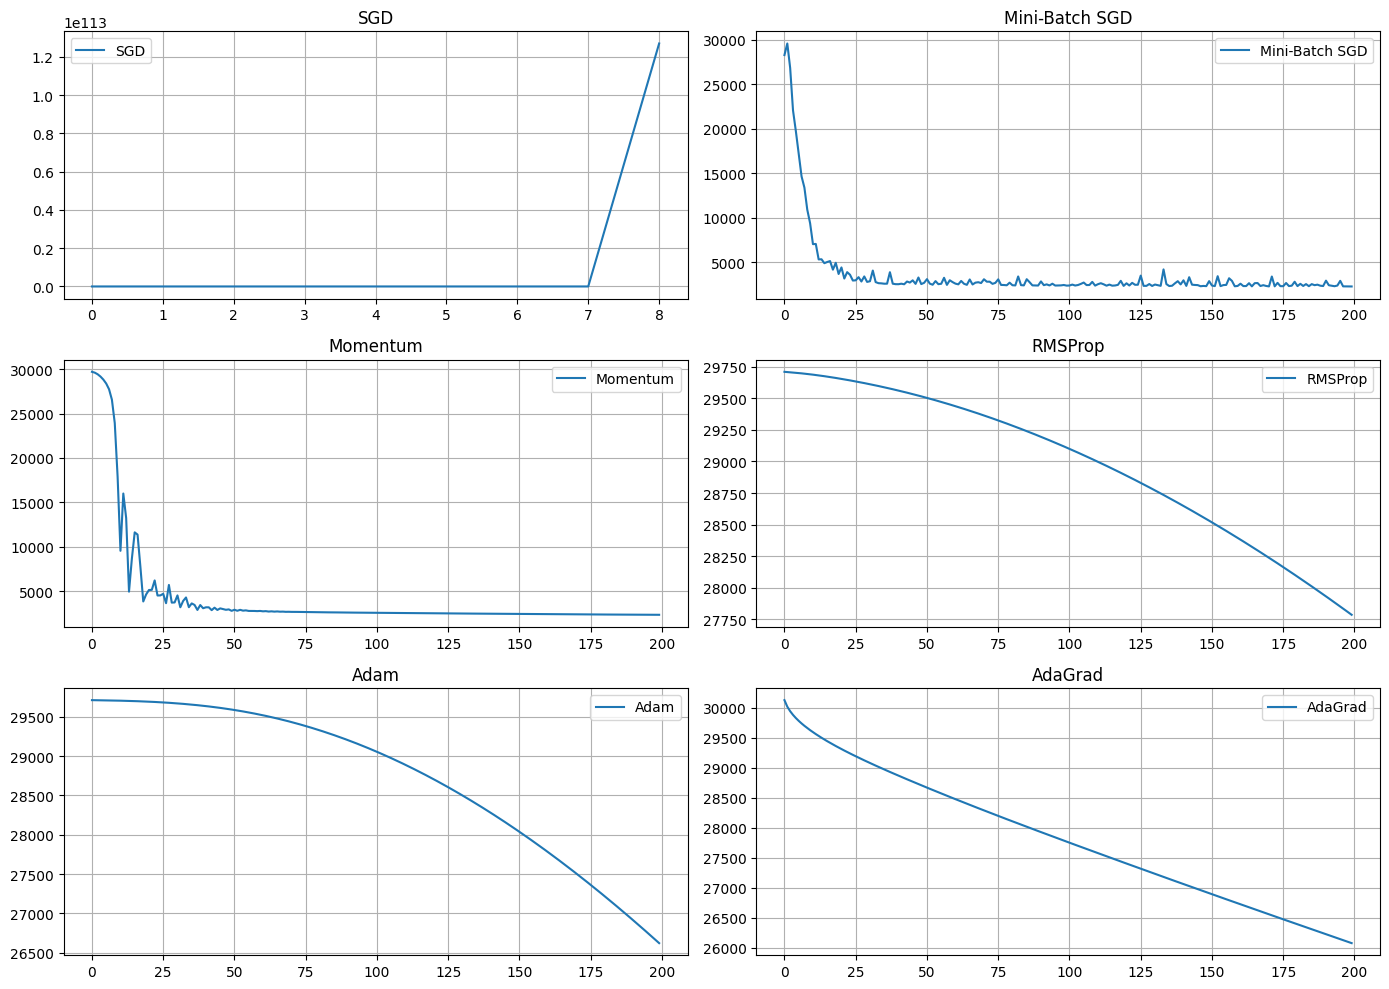

In [56]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 10))

# 3 rows, 2 columns → positions 1 to 6
plt.subplot(3, 2, 1)
plt.plot(losses_sgd, label='SGD')
plt.title('SGD')
plt.grid(True)
plt.legend()  # show label

plt.subplot(3, 2, 2)
plt.plot(losses_sgd_mini, label='Mini-Batch SGD')
plt.title('Mini-Batch SGD')
plt.grid(True)
plt.legend()

plt.subplot(3, 2, 3)
plt.plot(losses_mom, label='Momentum')
plt.title('Momentum')
plt.grid(True)
plt.legend()

plt.subplot(3, 2, 4)
plt.plot(losses_rms, label='RMSProp')
plt.title('RMSProp')
plt.grid(True)
plt.legend()

plt.subplot(3, 2, 5)
plt.plot(losses_adam, label='Adam')
plt.title('Adam')
plt.grid(True)
plt.legend()


plt.subplot(3, 2, 6)
plt.plot(losses_adagrad, label='AdaGrad')
plt.title('AdaGrad')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

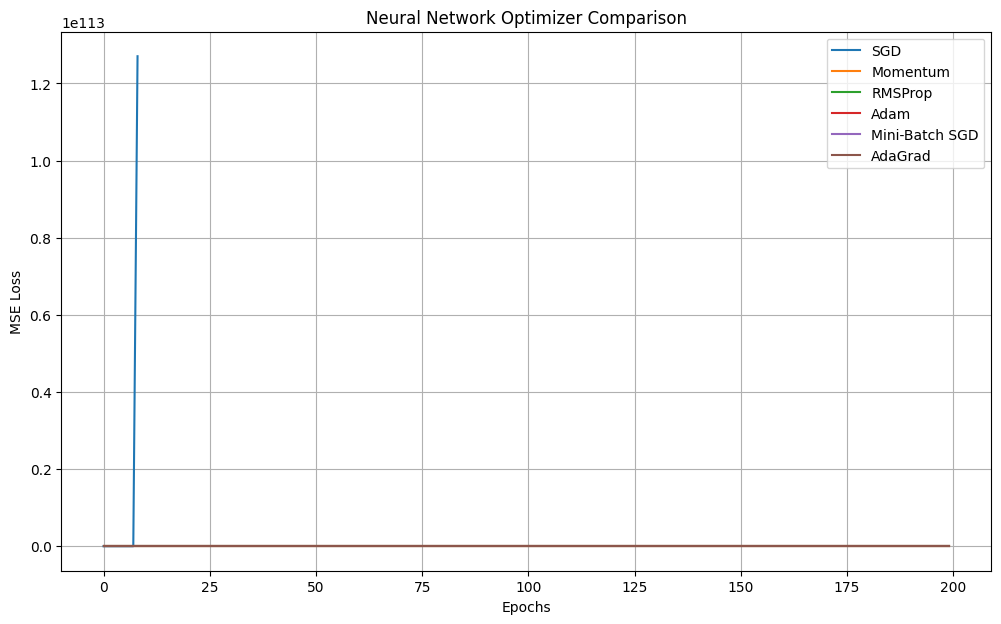

In [57]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 7))  # larger figure for clarity

# Plot loss for each optimizer
plt.plot(losses_sgd, label='SGD')
plt.plot(losses_mom, label='Momentum')
plt.plot(losses_rms, label='RMSProp')
plt.plot(losses_adam, label='Adam')
plt.plot(losses_sgd_mini, label='Mini-Batch SGD')
plt.plot(losses_adagrad, label='AdaGrad')

# Labels and title
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.title('Neural Network Optimizer Comparison')

# Show legend and grid
plt.legend()
plt.grid(True)

# Display the plot
plt.show()